# Favorable bet bankruptcy

Adapted from Nassim Taleb

Let $V_N$ be capital at discrete bet $N$ (or total number of bets as you can infer), $V_0$ be initial endowment,
$p$ is the probability of a single bet loss (total number of losses at $L$) and
$1-p$ is the probability of a single bet win (total number of wins at $W$).

$$
    V_N = V_0 (1 + p)^N \approx V_0 (1 + l)^{W} (1 - l)^{L} 
$$

But $L/N = p$, $W/N = 1 - p$ at large $N$, 
also $(V_N/V_0)^{1/N} = 1 + r$
thanks to Kelly, we have by law of large numbers: 

$$
    \lim_{N \rightarrow \infty}
    \log(1+r) \rightarrow \log((1+l)^{1-p} (1-l)^{p})
    = (1-p) \log (1 + l) + p \log(1 - l)
$$

The maximum is obtained when differentiating $(1-p) \log (1 + l) + p \log(1 - l)$ with respect to $l$. Maximising the $\log(1+r)$ is the same as maximising $r$ we have:

$$
    \frac{\partial(\log(1+r))}{\partial l} =  \frac{1-p}{1+l} - \frac{p}{1-l} = \frac{l + 2p - 1}{l^2 - 1}
$$

This is zero when $l = 1 - 2p$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.pyplot import figure as fig
sns.set_theme()

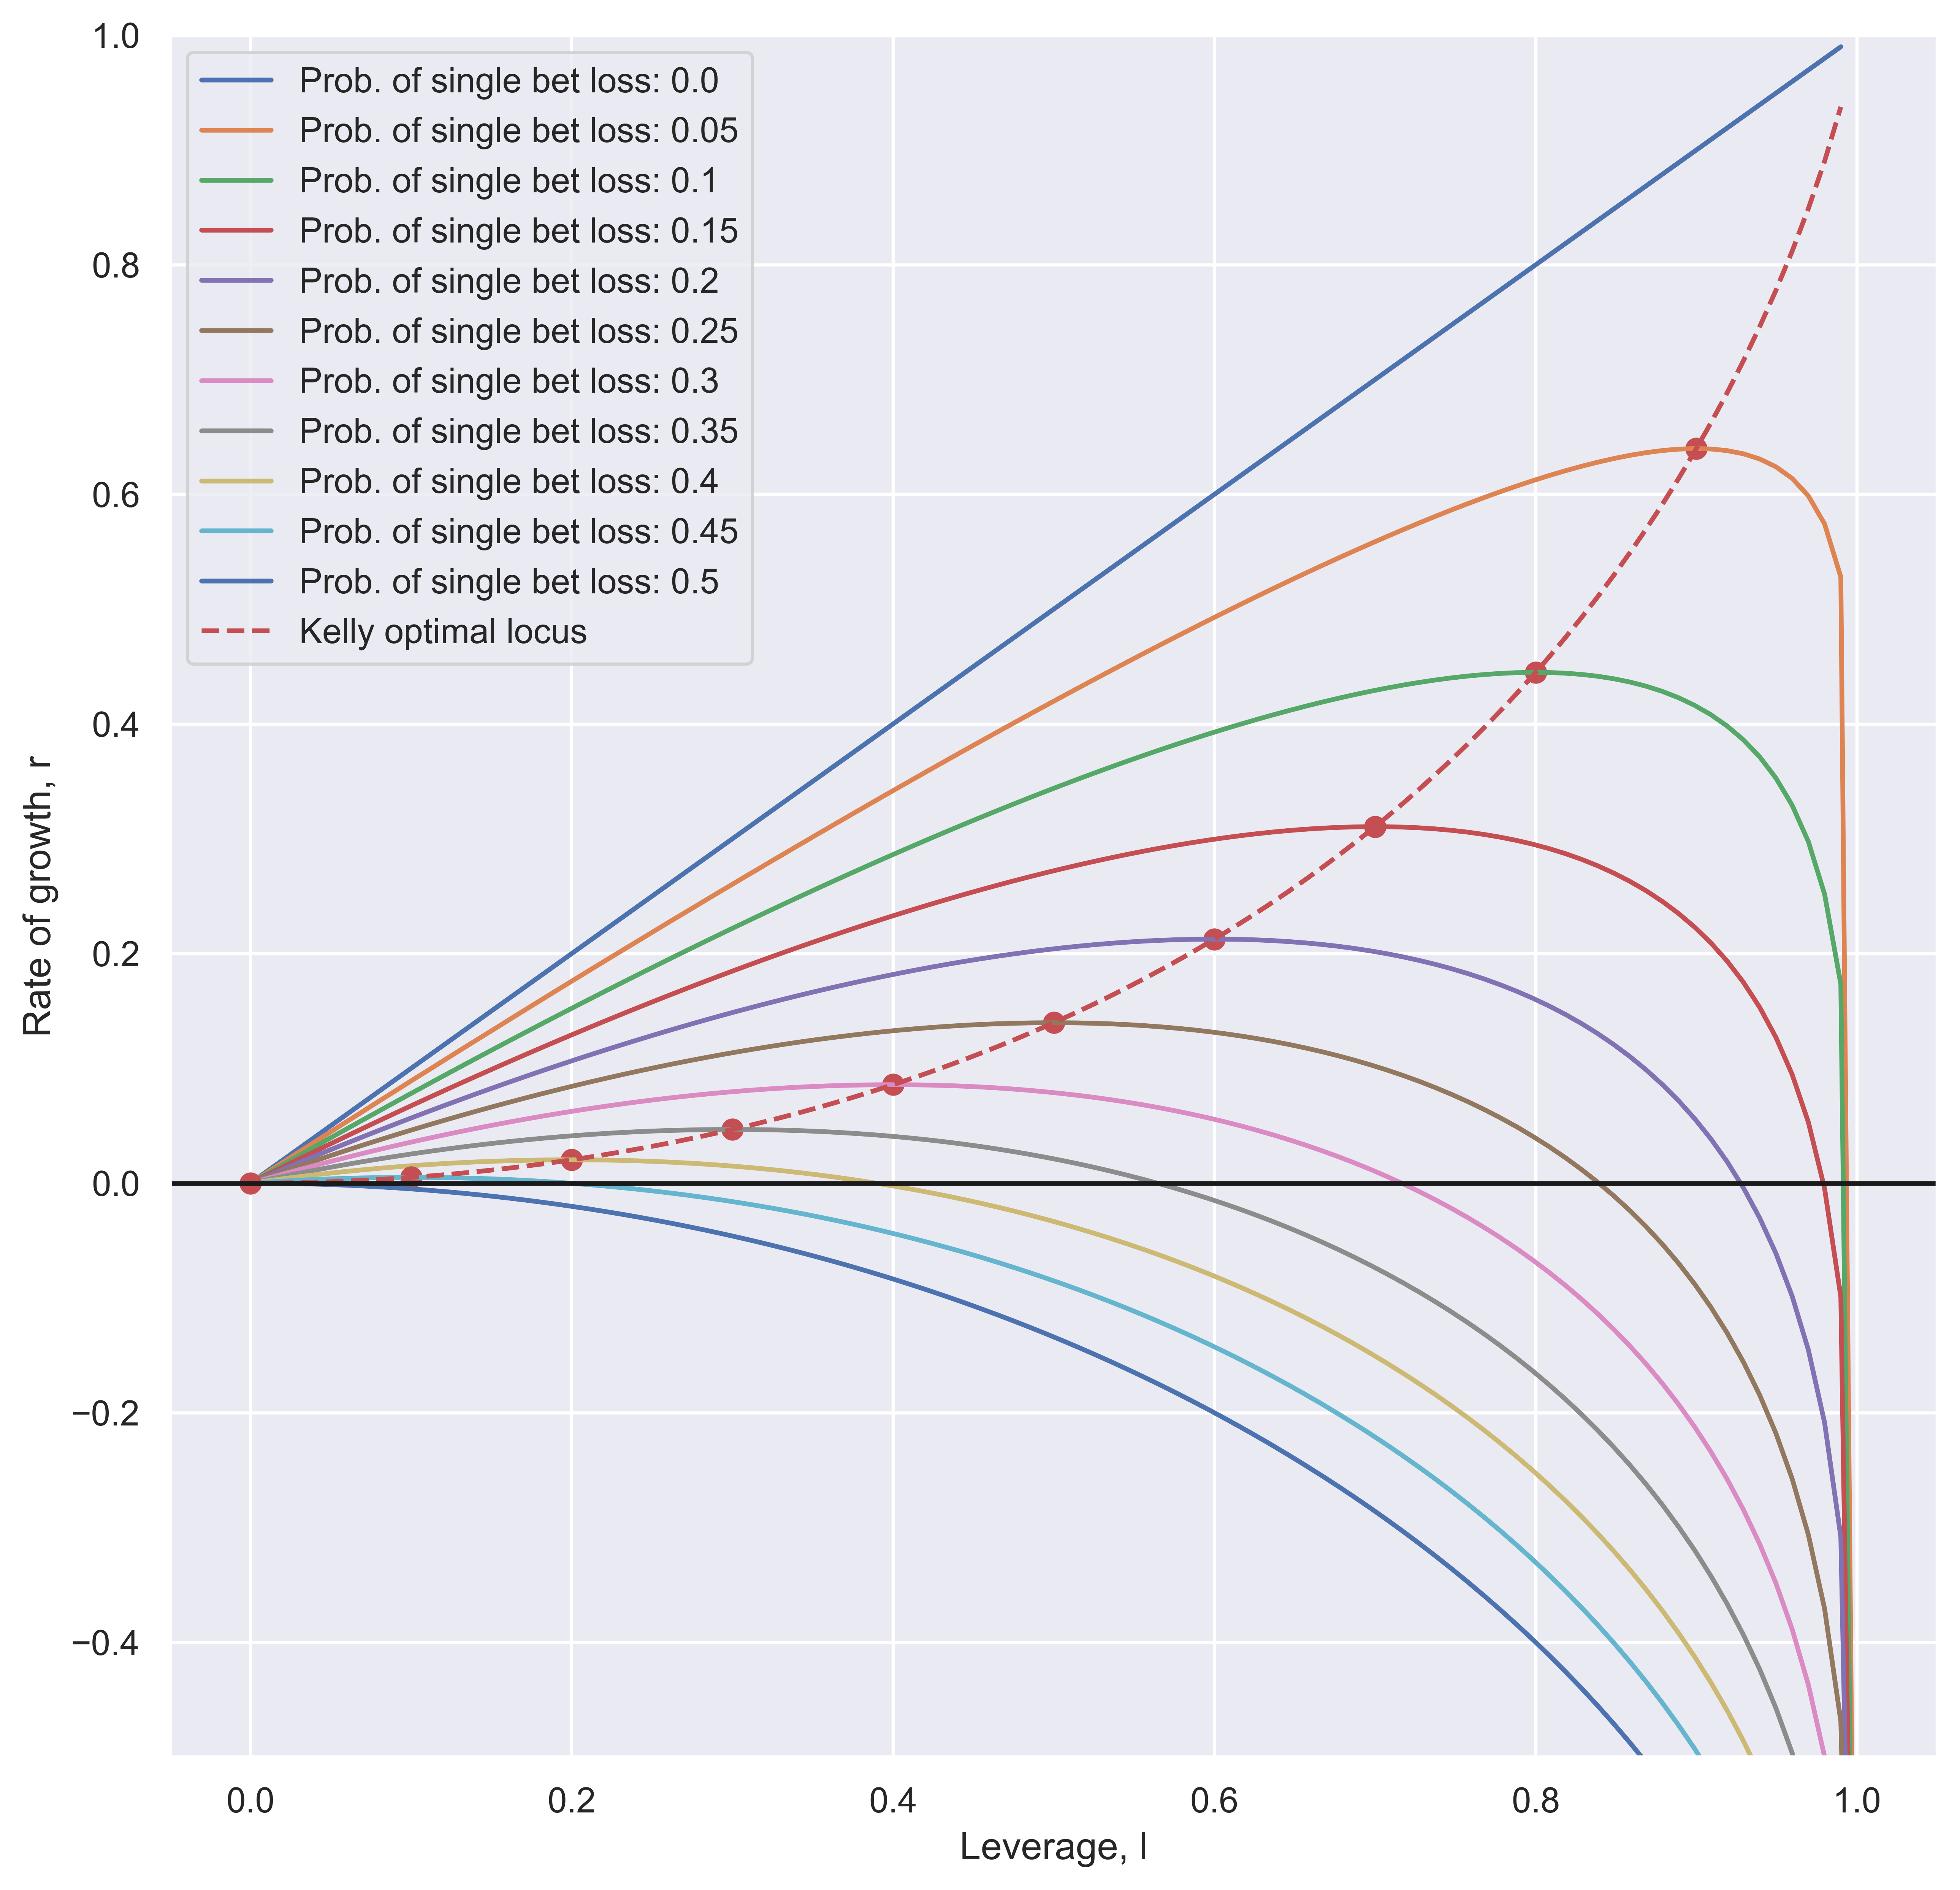

In [21]:
warnings.filterwarnings('ignore')

def KD(N=10):
    """
    Draws the rate of growth against
    leverage curve, given the number
    of divisions wanted N:
    """

    N += 1

    pr = np.linspace(0, 0.5, N)
    fig(figsize=(10, 10), dpi=600)


    for i in range(0, len(pr)):
        p = np.around(pr[i], decimals=5)
        lo = 1 - 2 * p
        ro = np.exp(p * np.log(1 - lo) + (1 - p) * np.log(lo + 1)) - 1
        plt.plot(lo, ro, 'ro')

        l = np.linspace(0, 1, 100)
        r = np.exp(p * np.log(1 - l) + (1 - p) * np.log(l + 1)) - 1
        pl = 'Prob. of single bet loss: ' + str(p)
        if N < 20:
            plt.plot(l, r, label=pl)
        else:
            plt.plot(l, r, 'b', label=pl)
            
        plt.ylabel('Rate of growth, r')
        plt.xlabel('Leverage, l')

    ll = np.linspace(0, 1, 100)
    rl = np.exp(0.5 * (1 - ll) * np.log(1 - ll) + (1 - 0.5 * (1 - ll))
                * np.log(ll + 1)) - 1
    plt.plot(ll, rl, 'r--', label='Kelly optimal locus')
    
    if N < 20:
            plt.legend()
    
    plt.axhline(y=0, color='k', linestyle='-')
    plt.ylim([-0.5, 1])    

KD(10)

In [22]:
def KB(
    p,
    l=0,
    N=10000,
    H=4,
    ):
    """
    p is the probability of losing
    l is the leverage of the bet
    N is the number of bets taken
    H is the number of histories to have
    """

    if l == 0:
        l = 1 - 2 * p
    T = H * [0]
    for i in range(0, len(T)):
        K = 1
        for j in range(0, N):
            d = K * l * (2 * np.random.binomial(1, 1 - p, 1)[0] - 1)
            K += d
        T[i] = np.around(K ** (1 / N), decimals=5)
    print(T)

In [25]:
KB(0.3, 0.7)

[0.99915, 1.02052, 1.00158, 1.00192]
